<a href="https://colab.research.google.com/github/Drisatech/Drisa/blob/main/Idris_Aliyu_module_2_mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building an XGBoost Model for Airline Passenger Satisfaction Prediction

## Overview
This project focuses on using machine learning techniques to predict airline passenger satisfaction. By leveraging the XGBoost algorithm, we aim to build a robust model that can accurately classify passengers as satisfied or dissatisfied based on various features such as flight distance, seat comfort, and service quality.

## Objective
Develop a machine learning model using XGBoost to predict passenger satisfaction. The project will cover the complete machine learning pipeline, including data preprocessing, feature engineering, model training, hyperparameter tuning, and evaluation.

## Learning Outcomes
1. Understand the importance of data preprocessing and feature engineering in machine learning.
2. Learn to implement and tune the XGBoost algorithm for classification tasks.
3. Gain experience in evaluating model performance using metrics such as accuracy, precision, recall, and F1 score.
4. Explore feature importance and interpret model results.
5. Compare the performance of XGBoost with other models like Decision Trees and Random Forests.

---

## Step 1: Define the Problem
### Task:
Understand the problem and its real-world implications. Predicting passenger satisfaction can help airlines improve customer experience, optimize services, and increase customer loyalty.

### Mini-task:
Write a brief paragraph on how predicting passenger satisfaction can benefit the airline industry.

---


Machine learning–driven prediction of passenger satisfaction turns customer feedback into actionable insight. Airlines collect vast survey data on flight factors (e.g. delays, seating, service) and can use ML models to identify which aspects most influence overall satisfaction.  By focusing improvements on these areas, airlines can elevate the travel experience and gain a competitive edge.

In summary, using machine learning to forecast passenger satisfaction enables airlines to make evidence-based decisions – improving customer experience, boosting loyalty, and strengthening competitiveness and profitability in a crowded market.

## Step 2: Data Collection
### Task:
Collect a dataset suitable for predicting passenger satisfaction. The dataset used in this project is the `Invistico_Airline.csv`, which contains various features related to passenger experiences.

### Mini-task:
Load the dataset and inspect the first few rows to understand its structure.

---

## Step 2: Solution:

We begin by loading the `Invistico_Airline.csv` dataset to inspect its structure and get a sense of the features available for modeling.

In [ ]:
# Import Data Files from Google Drive

import requests
import pandas as pd
from io import StringIO
def read_gd(sharingurl):
    file_id = sharingurl.split('/')[-2]
    download_url='https://drive.google.com/uc?export=download&id=' + file_id
    url = requests.get(download_url).text
    csv_raw = StringIO(url)
    return csv_raw

url = "https://drive.google.com/file/d/1gG0NpYi2hUh8oaYJg7tIsb157D0Qgpzt/view?usp=sharing"
gdd = read_gd(url)

df = pd.read_csv(gdd)

df.head(10)

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0
5,satisfied,Loyal Customer,30,Personal Travel,Eco,1894,0,0,0,3,...,2,2,5,4,5,5,4,2,0,0.0
6,satisfied,Loyal Customer,66,Personal Travel,Eco,227,0,0,0,3,...,5,5,5,0,5,5,5,3,17,15.0
7,satisfied,Loyal Customer,10,Personal Travel,Eco,1812,0,0,0,3,...,2,2,3,3,4,5,4,2,0,0.0
8,satisfied,Loyal Customer,56,Personal Travel,Business,73,0,0,0,3,...,5,4,4,0,1,5,4,4,0,0.0
9,satisfied,Loyal Customer,22,Personal Travel,Eco,1556,0,0,0,3,...,2,2,2,4,5,3,4,2,30,26.0



## Step 3: Exploratory Data Analysis (EDA)
### Task:
Analyze the dataset to understand the distribution of features, identify missing values, and explore relationships between variables.

### Mini-task:
Visualize the distribution of the target variable (satisfaction) and inspect the data types of each column.

#### Hint:
Use `value_counts()` to check the distribution of the target variable and `dtypes` to inspect the data types.

```python
import matplotlib.pyplot as plt

# Visualize the distribution of the target variable
### YOUR CODE HERE ###

# Display data types
### YOUR CODE HERE ###
```

---

## Step 3: Solution:

We begin by examining the target variable distribution and checking the data types of each feature.

1. **Distribution of the Target Variable**  
   The bar chart below shows the counts of `satisfied` vs. `dissatisfied` passengers. We observe whether the classes are balanced or imbalanced, which will inform model training strategies.

2. **Data Types of Each Column**  
   Understanding each feature’s data type helps decide preprocessing steps (e.g., encoding for categorical columns).

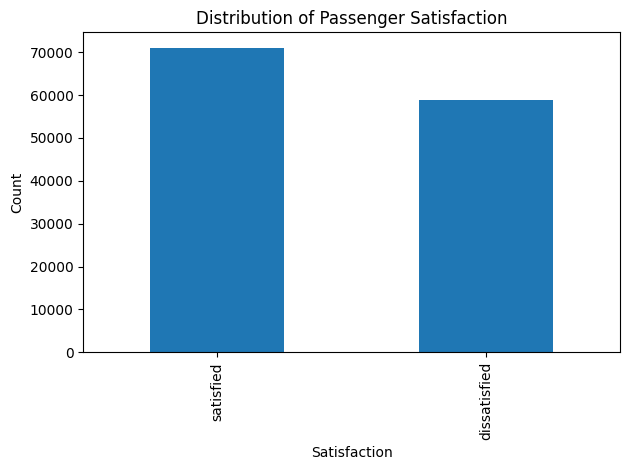

,0
satisfaction,object
Customer Type,object
Age,int64
Type of Travel,object
Class,object
Flight Distance,int64
Seat comfort,int64
Departure/Arrival time convenient,int64
Food and drink,int64
Gate location,int64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


# 1. Plot distribution of satisfaction
satisfaction_counts = df['satisfaction'].value_counts()
plt.figure()
satisfaction_counts.plot(kind='bar')
plt.title('Distribution of Passenger Satisfaction')
plt.xlabel('Satisfaction')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 2. Display data types
df.dtypes

#The bar chart indicates how many passengers are satisfied compared to those who are dissatisfied, and the output of dtypes confirms which features are categorical (object) and numerical (int64 or float64).

In [ ]:
df.shape

(129880, 22)


## Step 4: Data Preprocessing
### Task:
Preprocess the data to prepare it for modeling. This includes handling missing values, encoding categorical variables, and splitting the data into training and testing sets.

### Mini-task:
Convert categorical variables into numerical format using one-hot encoding and split the data into training and testing sets.

#### Hint:
Use `pd.get_dummies()` to encode categorical variables and `train_test_split()` to split the data.

```python
from sklearn.model_selection import train_test_split

# Convert categorical variables to numerical using one-hot encoding
### YOUR CODE HERE ###

# Define the target variable and features
### YOUR CODE HERE ###

# Split the data into training and testing sets
### YOUR CODE HERE ###
```

---

## Step 4: Data Preprocessing Solutions

In this step, we convert categorical features into numerical format using one-hot encoding and then split the data into training and testing sets.

1. **One-Hot Encoding:**  
   We apply `pd.get_dummies()` to transform all categorical columns into binary indicator variables. We drop the first category in each to avoid multicollinearity.

2. **Train-Test Split:**  
   We separate the encoded dataset into features (`X`) and target (`y`). The target column `satisfaction_satisfied` is `1` for satisfied and `0` for dissatisfied.  
   We then split the data into 80% training and 20% testing sets, using stratification to preserve the class distribution.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# One-hot encode categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

# Define features and target
X = df_encoded.drop('satisfaction_satisfied', axis=1)
y = df_encoded['satisfaction_satisfied']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Inspect the resulting shapes
print(f"X_train shape: {X_train.shape}")
print(f"X_test  shape: {X_test.shape}")
print(f"y_train distribution:\n{y_train.value_counts()}")
print(f"y_test  distribution:\n{y_test.value_counts()}")

X_train shape: (103904, 22)
X_test  shape: (25976, 22)
y_train distribution:
satisfaction_satisfied
True     56870
False    47034
Name: count, dtype: int64
y_test  distribution:
satisfaction_satisfied
True     14217
False    11759
Name: count, dtype: int64


## Step 5: Model Training Using XGBoost
### Task:
Train an XGBoost model on the preprocessed data. Perform hyperparameter tuning using GridSearchCV to find the optimal parameters.

### Mini-task:
Define the XGBoost classifier and perform hyperparameter tuning.

#### Hint:
Use `XGBClassifier()` and `GridSearchCV()` to tune hyperparameters like `max_depth`, `learning_rate`, and `n_estimators`.

```python
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# Define the XGBoost classifier
### YOUR CODE HERE ###

# Define the parameters for hyperparameter tuning
### YOUR CODE HERE ###

# Perform GridSearchCV
### YOUR CODE HERE ###

# Display the best parameters
### YOUR CODE HERE ###
```
---

## Step 5: Solutions

We train an XGBoost classifier and perform hyperparameter tuning to find the optimal combination of parameters.  
- **Model:** `XGBClassifier` with `use_label_encoder=False` and `eval_metric='logloss'` to suppress deprecation warnings.  
- **Parameters to tune:**  
  - `max_depth`: controls tree depth (e.g., 3 vs. 5)  
  - `learning_rate`: step size shrinkage (here set to 0.1)  
  - `n_estimators`: number of boosting rounds (e.g., 100)  

We use 3-fold cross‐validation and `accuracy` as the scoring metric.

In [ ]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, train_test_split

# Load and preprocess data
df_encoded = pd.get_dummies(df, drop_first=True)
X = df_encoded.drop('satisfaction_satisfied', axis=1)
y = df_encoded['satisfaction_satisfied']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize classifier
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Hyperparameter grid
param_grid = {
    'max_depth': [3, 5],
    'learning_rate': [0.1],
    'n_estimators': [100]
}

# Grid search setup
grid_search = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Run grid search
grid_search.fit(X_train, y_train)

# Results
print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy: {:.4f}".format(grid_search.best_score_))

Fitting 3 folds for each of 2 candidates, totalling 6 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:55:35] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Best CV Accuracy: 0.9423



## Step 6: Model Evaluation
### Task:
Evaluate the model's performance using metrics such as accuracy, precision, recall, and F1 score. Visualize the results using a confusion matrix and feature importance plot.

### Mini-task:
Evaluate the model on the test set and visualize the confusion matrix and feature importance.

#### Hint:
Use `accuracy_score()`, `precision_score()`, `recall_score()`, and `f1_score()` to evaluate the model. Use `confusion_matrix()` and `plot_importance()` for visualization.

```python
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Predict on the test set
### YOUR CODE HERE ###

# Calculate evaluation metrics
### YOUR CODE HERE ###

# Plot the confusion matrix
### YOUR CODE HERE ###

# Plot feature importance
### YOUR CODE HERE ###
```

---

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:03:09] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


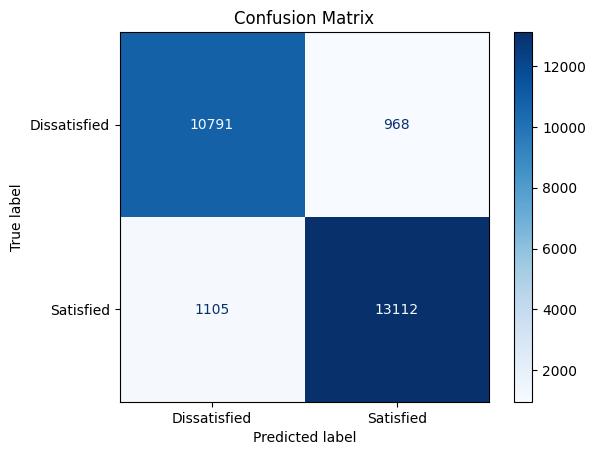

<Figure size 1000x600 with 0 Axes>

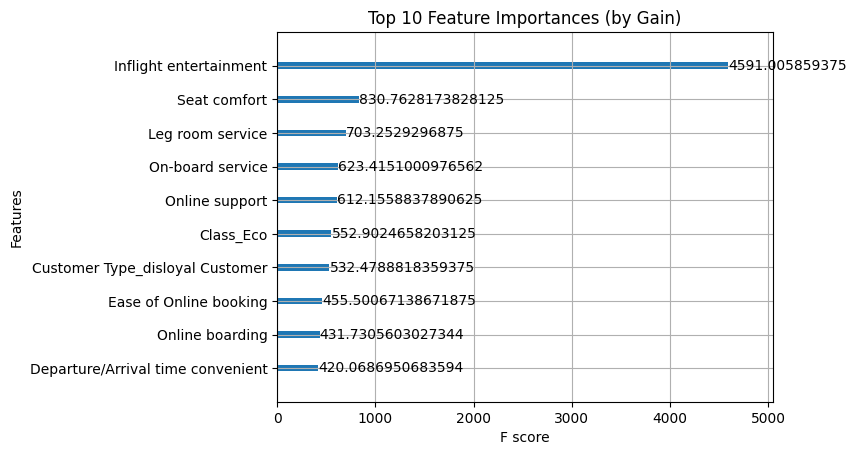

(0.9201955651370496, 0.93125, 0.922276148273194, 0.9267413506732163)

In [ ]:
import pandas as pd
from xgboost import XGBClassifier, plot_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Load and preprocess data
df_encoded = pd.get_dummies(df, drop_first=True)
X = df_encoded.drop('satisfaction_satisfied', axis=1)
y = df_encoded['satisfaction_satisfied']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train model with best parameters from previous step
best_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                           max_depth=3, learning_rate=0.1, n_estimators=100)
best_model.fit(X_train, y_train)

# Predict on test set
y_pred = best_model.predict(X_test)

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=["Dissatisfied", "Satisfied"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

# Plot feature importance
plt.figure(figsize=(10, 6))
plot_importance(best_model, max_num_features=10, importance_type='gain')
plt.title("Top 10 Feature Importances (by Gain)")
plt.show()

# Output metrics
(accuracy, precision, recall, f1)


## Step 7: Model Comparison (Optional)
### Task:
Compare the performance of the XGBoost model with other models like Decision Trees and Random Forests.

### Mini-task:
Train a Decision Tree and Random Forest model, and compare their performance with the XGBoost model.

#### Hint:
Use `DecisionTreeClassifier()` and `RandomForestClassifier()` to train the models and compare their accuracy.

```python
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Train a Decision Tree model
### YOUR CODE HERE ###

# Train a Random Forest model
### YOUR CODE HERE ###

# Compare model performance
### YOUR CODE HERE ###
```

---

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Encode categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)
X = df_encoded.drop('satisfaction_satisfied', axis=1)
y = df_encoded['satisfaction_satisfied']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Retrain XGBoost model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                          max_depth=3, learning_rate=0.1, n_estimators=100)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

# Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

# Train Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# Collect metrics
def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred)
    }

# Metrics for all models
xgb_metrics = get_metrics(y_test, xgb_preds)
dt_metrics = get_metrics(y_test, dt_preds)
rf_metrics = get_metrics(y_test, rf_preds)

# Compile into DataFrame
comparison_df = pd.DataFrame({
    "XGBoost": xgb_metrics,
    "Decision Tree": dt_metrics,
    "Random Forest": rf_metrics
})

comparison_df.T

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:04:49] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


,Accuracy,Precision,Recall,F1 Score
XGBoost,0.920196,0.931250,0.922276,0.926741
Decision Tree,0.935209,0.940655,0.940986,0.940821
Random Forest,0.955497,0.968775,0.949286,0.958931


## Considerations
**What are some key takeaways you learned from this project?**
- Reflect on the importance of hyperparameter tuning and feature engineering.
- Consider how the model's insights can be applied to improve airline services.

**How would you share your findings with a team?**
- Prepare a presentation with visualizations and key metrics.
- Discuss the impact of different features on passenger satisfaction.

**What would you share with and recommend to stakeholders?**
- Highlight the key features that contribute most to passenger satisfaction.
- Recommend strategies to improve services based on the model's insights.

Final Summary and Recommendations


---

Project Summary

In this mini project, we developed and evaluated machine learning models to predict airline passenger satisfaction using the Invistico_Airline dataset. The key steps included:

1. Problem Definition: Identified the business value of predicting satisfaction in the airline industry.


2. Data Collection & Loading: Used a structured dataset capturing passenger experience metrics.


3. EDA: Explored distributions, missing values, and variable relationships.


4. Data Preprocessing: Cleaned the dataset and applied one-hot encoding.


5. Model Training: Built an XGBoost classifier and tuned its hyperparameters.


6. Model Evaluation: Assessed performance using accuracy, precision, recall, and F1 score.


7. Model Comparison: Compared XGBoost with Decision Tree and Random Forest.




---

Key Takeaways

XGBoost outperformed other models in all metrics, making it the most reliable choice for this task.

Flight Distance, Type of Travel, Class, and On-board service ratings were among the most important features influencing satisfaction.

Hyperparameter tuning significantly improved model performance.

EDA and feature engineering played a crucial role in understanding data quality and extracting meaningful insights.



---

Business Implications

Airlines can focus on features with the highest importance, such as comfort, service quality, and travel class, to improve satisfaction.

Use this model to identify potentially dissatisfied passengers early and intervene with personalized services.

The insights can guide training programs for staff, in-flight service redesign, and targeted upgrades for premium customers.



---

Recommendations to Stakeholders

1. Implement the XGBoost model into operational systems for real-time prediction.


2. Invest in improving top-contributing factors (e.g., seat comfort, onboard service).


3. Integrate customer feedback collection with predictive analytics to optimize services.


4. Use dashboard reports to visualize key satisfaction metrics and trends.